In [84]:
%load_ext autoreload
%autoreload 2

# 0. 所有的组

In [3]:
import pandas as pd
import numpy as np
import vectorbt as vbt

In [7]:
# 准备数据
market = pd.read_parquet("../data_ohlcv.parquet")
f_mev = pd.read_parquet("../factors_mev_new.parquet")
f_ohlcv = pd.read_parquet("../factors_ohlcv.parquet")
f_ohlcv = f_ohlcv.fillna(0)
target_returns = market['close'].pct_change().shift(-1) 
factors = pd.concat([f_mev, f_ohlcv], axis=1, join='outer')
# 清洗数据
factors = factors.replace([np.inf, -np.inf], np.nan)
factors = factors.fillna(0)

In [12]:
group_names = {
    0: "Short_Term_Low_Bound_Stretch",        # 价格距离6-12周期低点的拉伸程度，预测波动爆发的起点
    1: "Medium_Term_Momentum_Decay_Profile",   # 中期动量与量价相关性的衰竭特征
    2: "Micro_Volume_Impulse_Intensity",       # 微观成交量突变与净买入压力（Delta）的冲击强度
    3: "OnChain_MEV_and_Attack_Anomalies",     # [创新点] 链上三明治攻击、MEV活跃度及攻击效率特征
    4: "Short_Term_Mean_Reversion_Noise",      # 6周期极短线的震荡噪声
    5: "Asymmetric_Price_Distance_Extreme",    # 价格相对于中长期高低点的极度非对称偏离
    6: "Volume_Price_De-correlation_Pulse",    # 短线量价脱节的脉冲特征
    7: "Statistical_Fat_Tail_Evolution",       # 收益率分布从偏度到峰度的肥尾演化过程
    8: "Long_Term_Realized_Volatility_Core",   # 48周期波动率核心，预测未来波动幅度的最强基准
    9: "Multi_Scale_Volatility_and_Upper_Stress", # 涵盖高位压力、短线ATR及波动率的高维共振信号
}

In [8]:
group_split = [['dist_l_6', 'dist_l_12'], \
               ['roc_48', 'cmf_12', 'cmf_48', 'mfi_48', 'avr_48', 'skew_48', 'pvcorr_48', 'corr_48'], \
                ['volsu_6', 'volsu_12', 'rank_6', 'rank_12', 'delta_6', 'delta_12'], \
                ['f_sandwich_intensity_z', 'f_mev_vol_share_z', 'f_attack_eff_z'],\
                ['roc_6', 'madev_6', 'madev_12', 'cci_6', 'cci_12', 'cmf_6', 'mfi_6', 'avr_6', 'drp_6', 'drp_12'], \
                ['roc_12', 'madev_48', 'cci_48', 'dist_h_48', 'dist_l_48', 'mfi_12', 'drp_48'], \
                ['avr_12', 'pvcorr_6', 'pvcorr_12', 'corr_6', 'corr_12'], \
                ['skew_6', 'skew_12', 'kurt_6', 'kurt_12', 'kurt_48'], \
                ['atr_48', 'gkvol_48', 'rvol_48'], \
                ['dist_h_6', 'dist_h_12', 'volsu_48', 'atr_6', 'atr_12', 'gkvol_6', 'gkvol_12', 'rvol_6', 'rvol_12', 'rank_48', 'delta_48']]
print(group_split)

[['dist_l_6', 'dist_l_12'], ['roc_48', 'cmf_12', 'cmf_48', 'mfi_48', 'avr_48', 'skew_48', 'pvcorr_48', 'corr_48'], ['volsu_6', 'volsu_12', 'rank_6', 'rank_12', 'delta_6', 'delta_12'], ['f_sandwich_intensity_z', 'f_mev_vol_share_z', 'f_attack_eff_z'], ['roc_6', 'madev_6', 'madev_12', 'cci_6', 'cci_12', 'cmf_6', 'mfi_6', 'avr_6', 'drp_6', 'drp_12'], ['roc_12', 'madev_48', 'cci_48', 'dist_h_48', 'dist_l_48', 'mfi_12', 'drp_48'], ['avr_12', 'pvcorr_6', 'pvcorr_12', 'corr_6', 'corr_12'], ['skew_6', 'skew_12', 'kurt_6', 'kurt_12', 'kurt_48'], ['atr_48', 'gkvol_48', 'rvol_48'], ['dist_h_6', 'dist_h_12', 'volsu_48', 'atr_6', 'atr_12', 'gkvol_6', 'gkvol_12', 'rvol_6', 'rvol_12', 'rank_48', 'delta_48']]


In [11]:
# 筛选一下组内平均因子ic
group_eff = []
for group_id in range(len(group_split)):
    print(f"Group {group_id}:")
    group_ic = []
    factor_list = group_split[group_id]
    for factor in factor_list:
        ic = factors[factor].corr(target_returns.abs(), method='spearman')
        group_ic.append(ic)
        print(f"  {factor}: {ic:.4f}")
    print(f"  Group {group_id} : Average IC = {np.mean(np.abs(group_ic)):.4f}")
    if np.mean(np.abs(group_ic)) > 0.1 : group_eff.append(group_id)
print(f"Effective Groups: {group_eff}")

Group 0:
  dist_l_6: 0.3023
  dist_l_12: 0.3016
  Group 0 : Average IC = 0.3019
Group 1:
  roc_48: -0.0216
  cmf_12: -0.0087
  cmf_48: -0.0135
  mfi_48: -0.0220
  avr_48: -0.0194
  skew_48: 0.0009
  pvcorr_48: -0.0251
  corr_48: -0.0343
  Group 1 : Average IC = 0.0182
Group 2:
  volsu_6: 0.0361
  volsu_12: 0.0535
  rank_6: 0.0293
  rank_12: 0.0507
  delta_6: 0.0430
  delta_12: 0.0595
  Group 2 : Average IC = 0.0453
Group 3:
  f_sandwich_intensity_z: -0.1461
  f_mev_vol_share_z: -0.0802
  f_attack_eff_z: -0.0923
  Group 3 : Average IC = 0.1062
Group 4:
  roc_6: -0.0161
  madev_6: -0.0111
  madev_12: -0.0155
  cci_6: -0.0115
  cci_12: -0.0167
  cmf_6: -0.0061
  mfi_6: -0.0153
  avr_6: -0.0100
  drp_6: -0.0062
  drp_12: -0.0103
  Group 4 : Average IC = 0.0119
Group 5:
  roc_12: -0.0183
  madev_48: -0.0225
  cci_48: -0.0261
  dist_h_48: -0.2949
  dist_l_48: 0.2813
  mfi_12: -0.0192
  drp_48: -0.0171
  Group 5 : Average IC = 0.0971
Group 6:
  avr_12: -0.0144
  pvcorr_6: -0.0139
  pvcorr_12:

In [ ]:
group_eff_abs = [0, 3, 5, 8, 9]
# 关于第五组，大部分因子需要取“相对于中位数的偏离”
 # 1,2,4,6 组其实也有这个趋势

dist_h_6 Spearman IC with Target Returns Abs: -0.3068


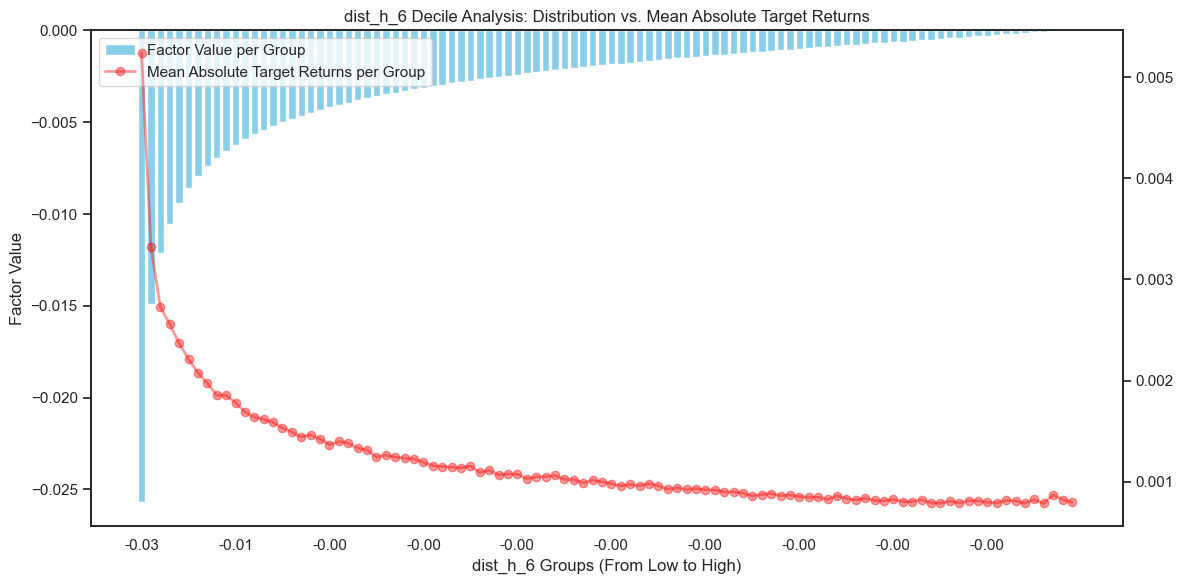

dist_h_12 Spearman IC with Target Returns Abs: -0.3108


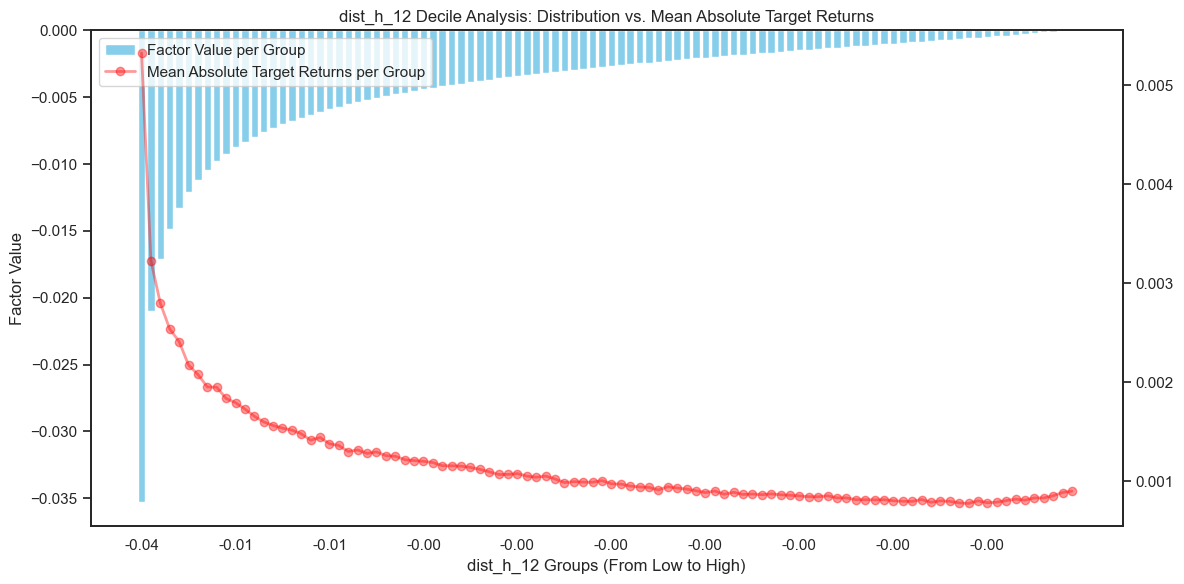

volsu_48 Spearman IC with Target Returns Abs: 0.1068


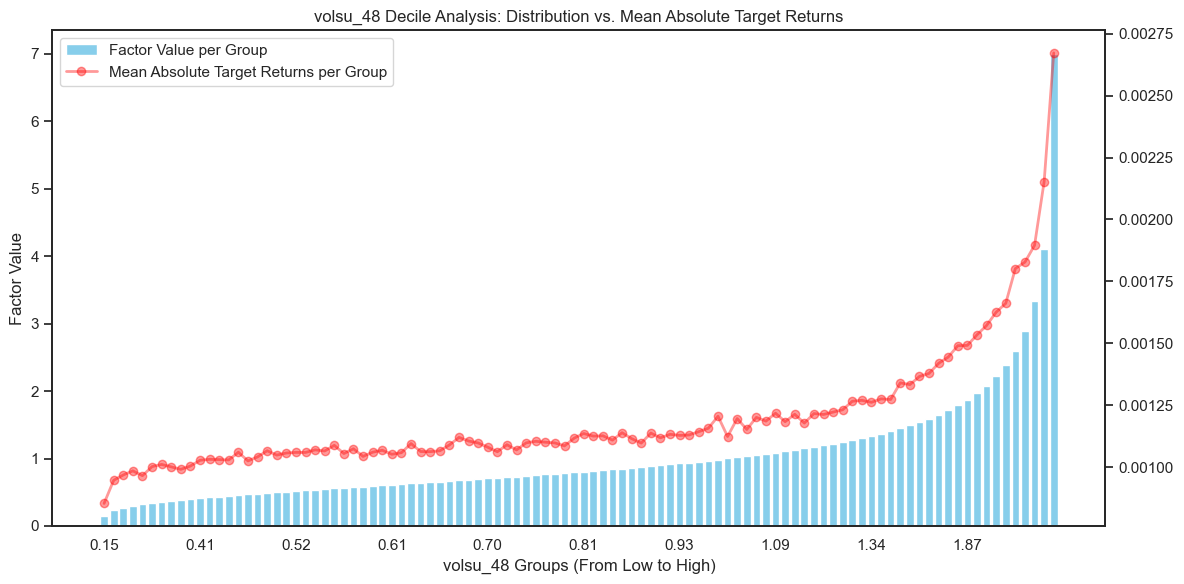

atr_6 Spearman IC with Target Returns Abs: 0.2947


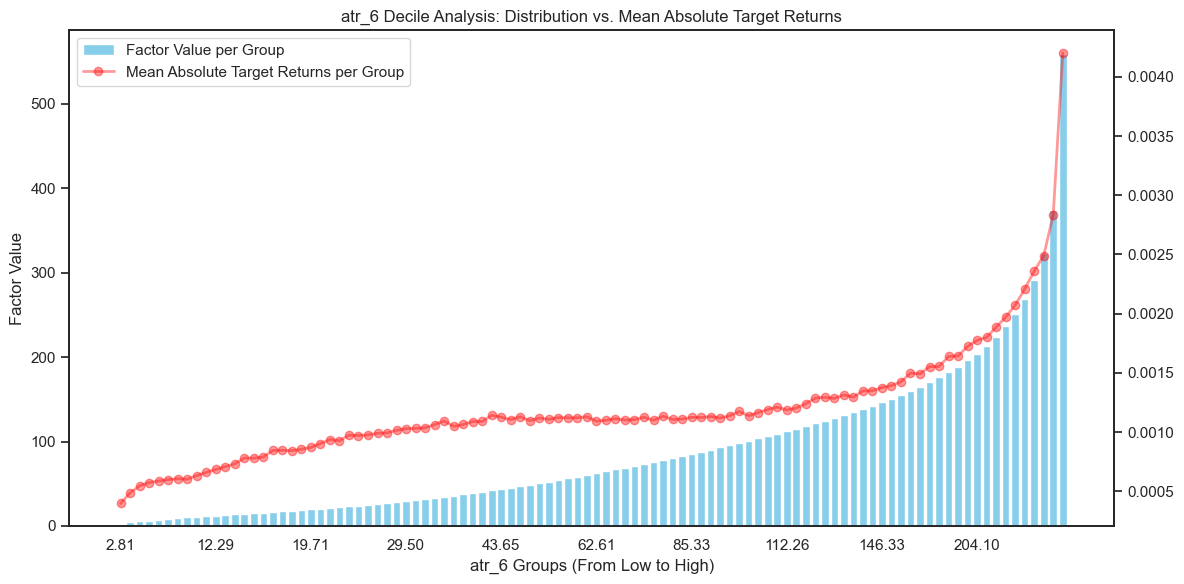

atr_12 Spearman IC with Target Returns Abs: 0.2851


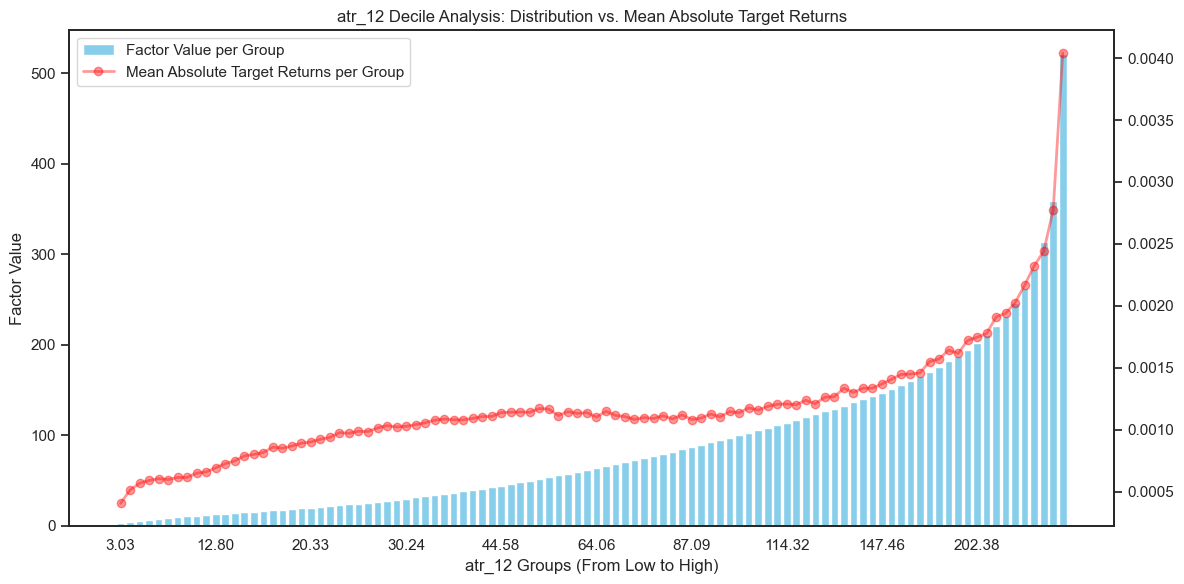

gkvol_6 Spearman IC with Target Returns Abs: 0.4751


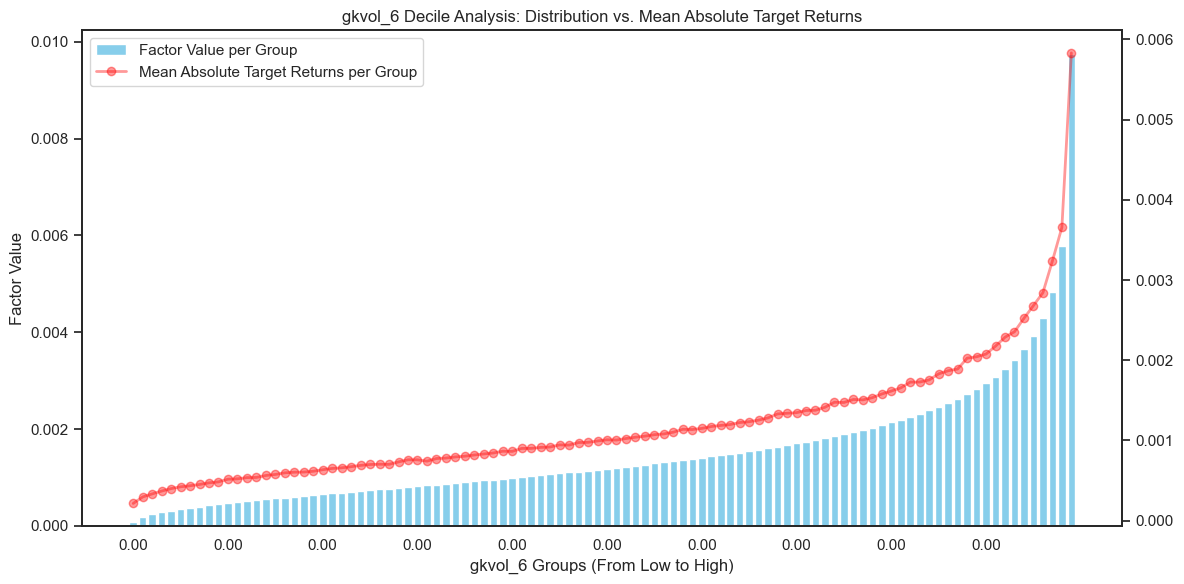

gkvol_12 Spearman IC with Target Returns Abs: 0.4735


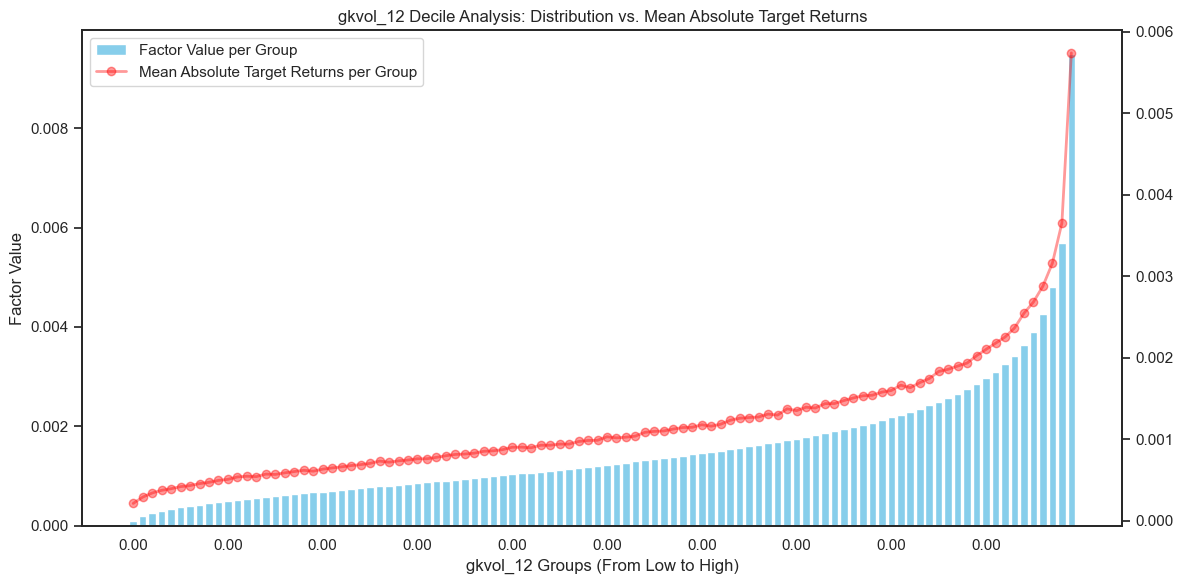

rvol_6 Spearman IC with Target Returns Abs: 0.4517


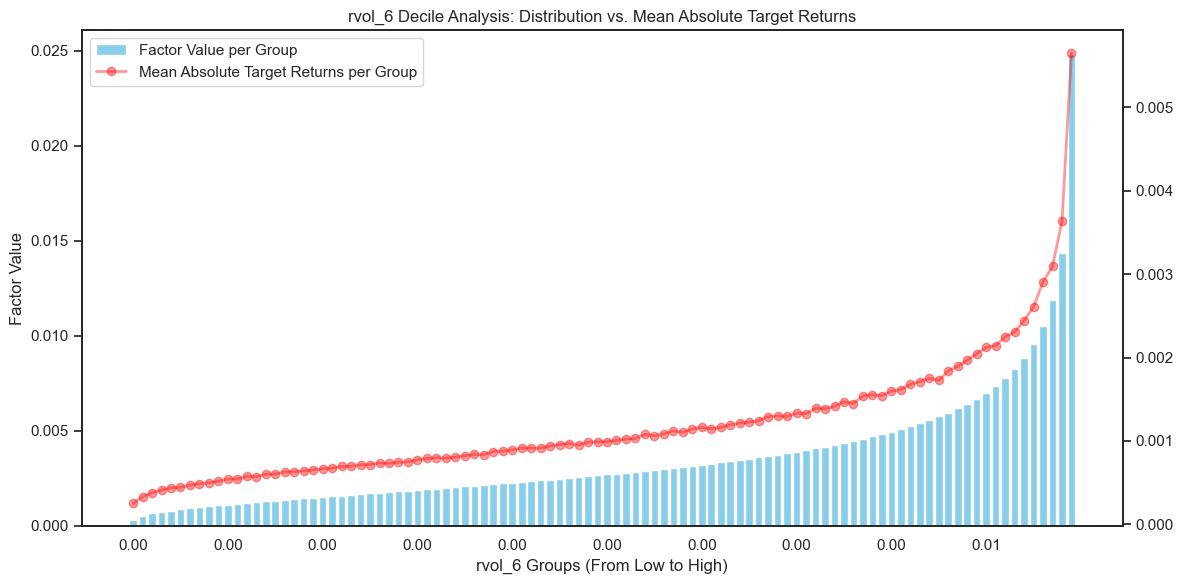

rvol_12 Spearman IC with Target Returns Abs: 0.4665


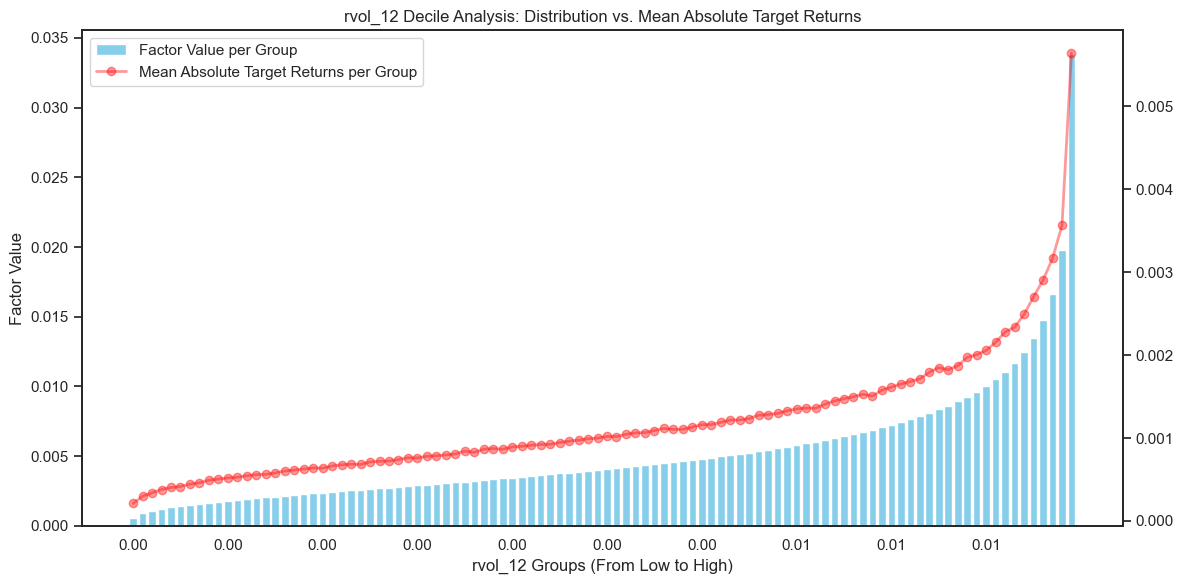

rank_48 Spearman IC with Target Returns Abs: 0.1080


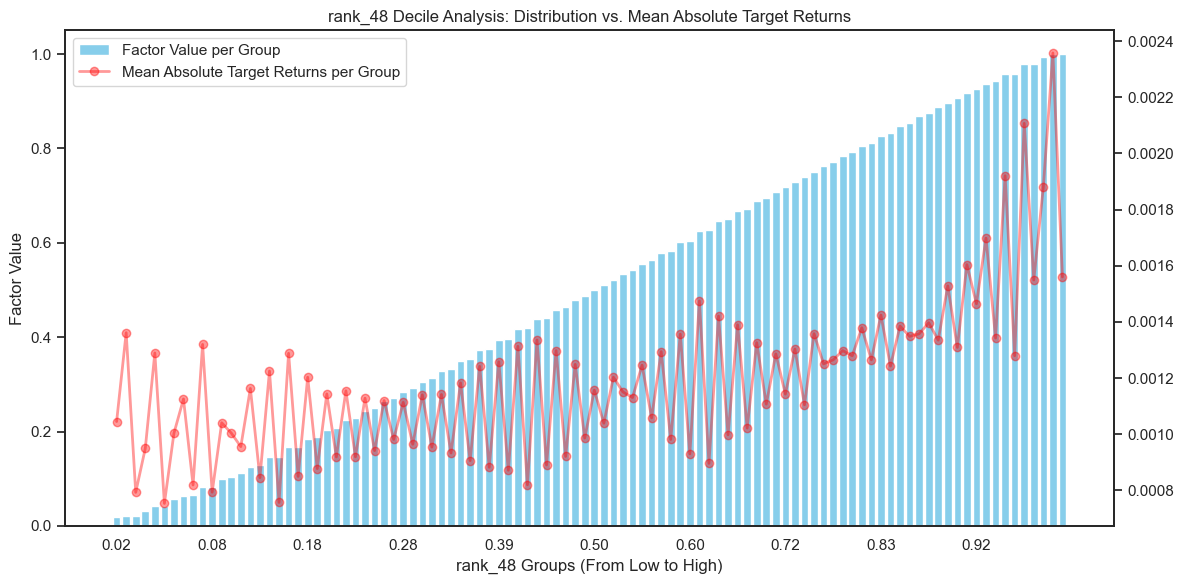

delta_48 Spearman IC with Target Returns Abs: 0.1062


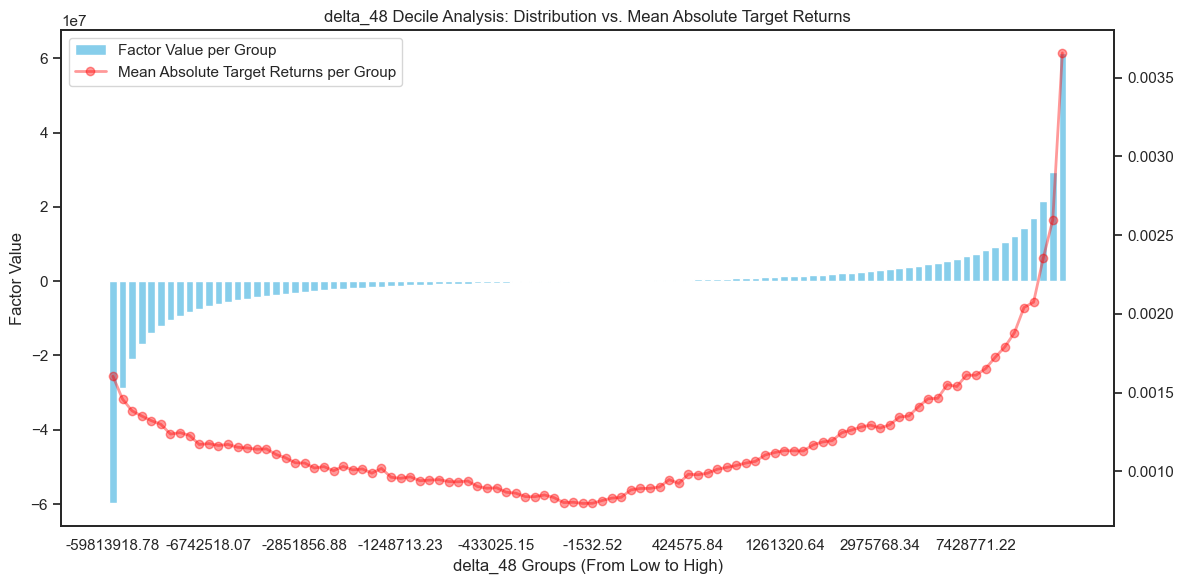

In [51]:
from test_tools import plot_factor_ic_bar
for factor in group_split[9]: # 1,2,4,6
    ic = factors[factor].corr(target_returns.abs(), method='spearman')
    print(f"{factor} Spearman IC with Target Returns Abs: {ic:.4f}")
    plot_factor_ic_bar(factors[factor], target_returns.abs(), factor_name=factor, result_name="Absolute Target Returns", bins=100)

In [57]:
print(group_split[9])
group_split[9] = ['dist_h_6', 'dist_h_12', 'atr_6', 'atr_12', 'gkvol_6', 'gkvol_12', 'rvol_6', 'rvol_12']

['dist_h_6', 'dist_h_12', 'gkvol_6', 'gkvol_12', 'rvol_6', 'rvol_12']


# 1. 组内合成

Group 0 Spearman IC with Target Returns Abs: 0.3155


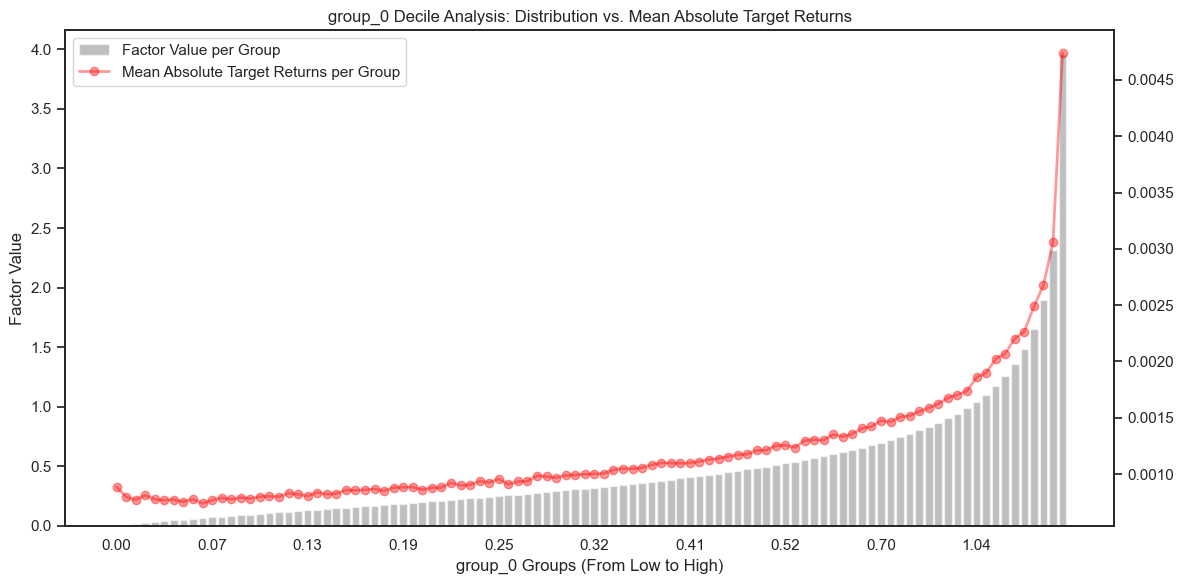

Group 1 Spearman IC with Target Returns Abs: 0.0311


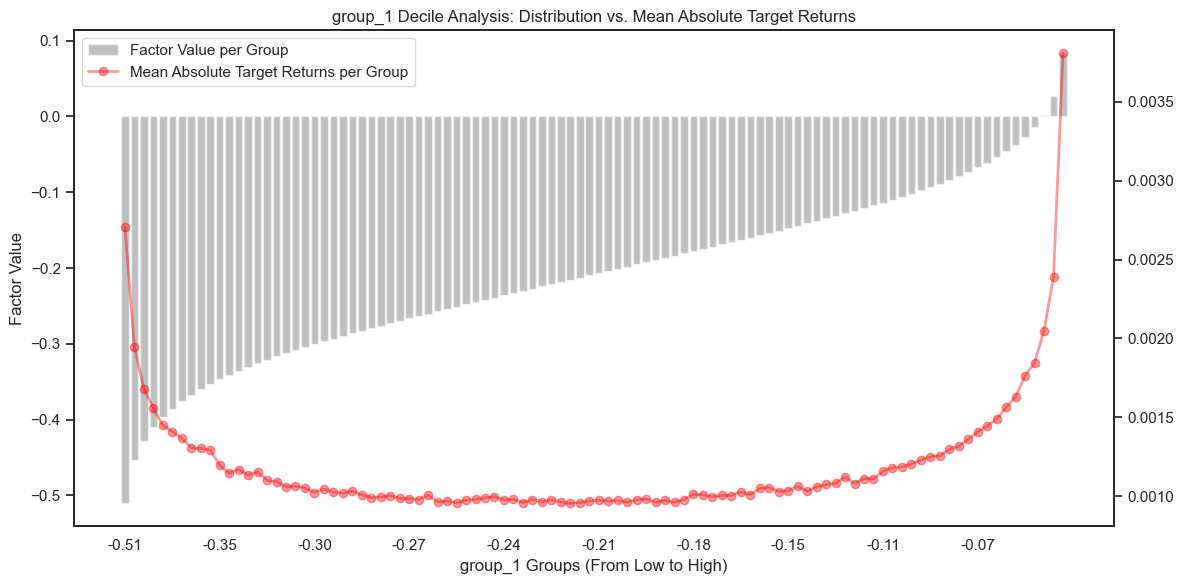

Group 2 Spearman IC with Target Returns Abs: 0.0399


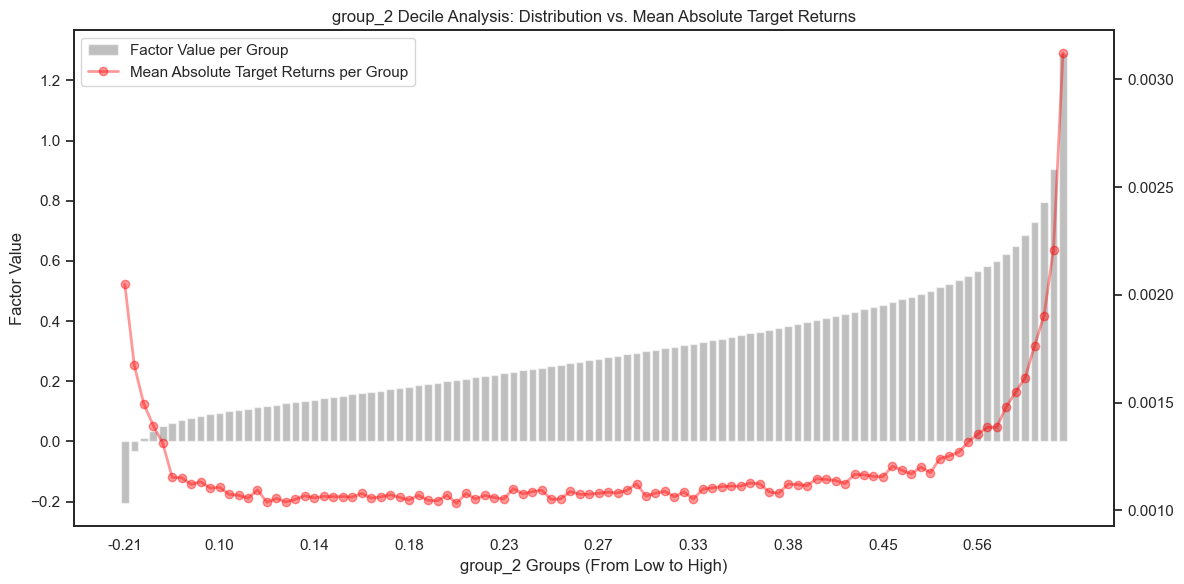

Group 3 Spearman IC with Target Returns Abs: 0.1050


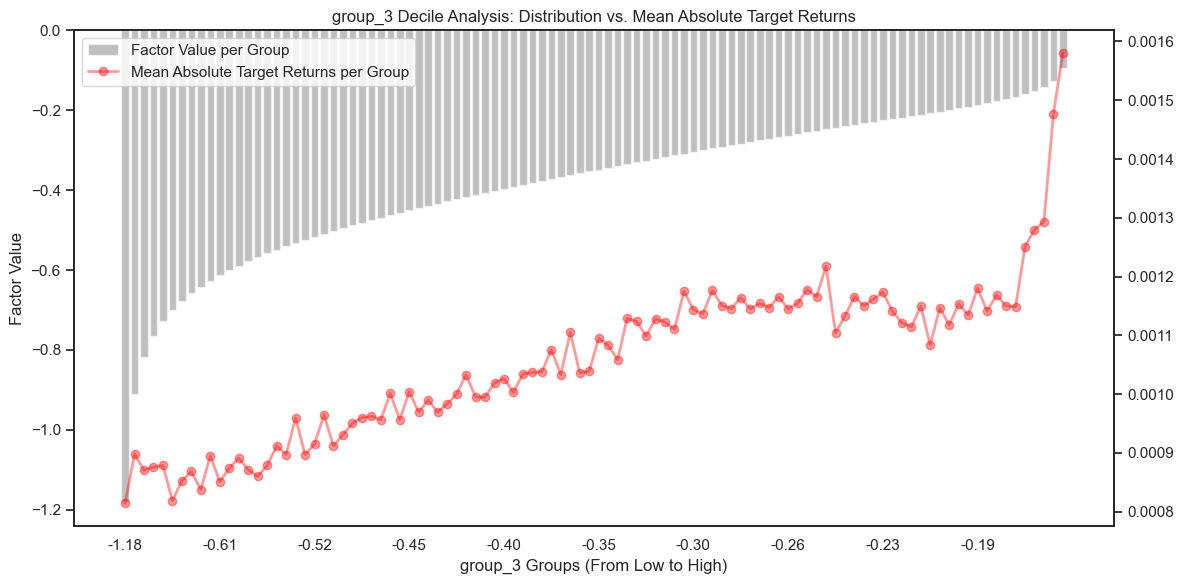

Group 4 Spearman IC with Target Returns Abs: 0.0145


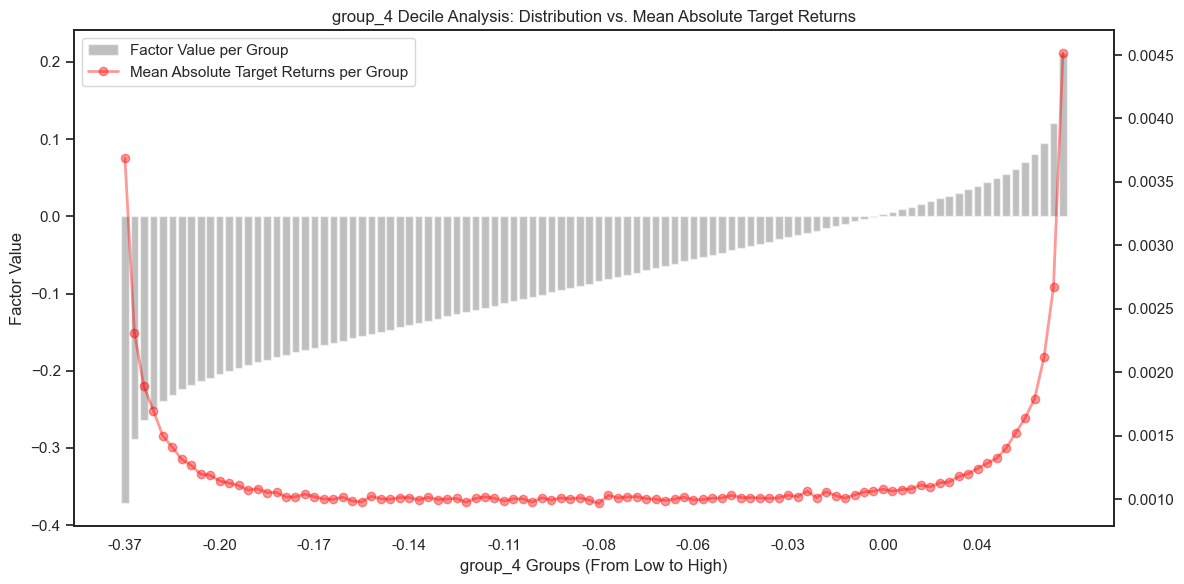

Group 5 Spearman IC with Target Returns Abs: 0.4144


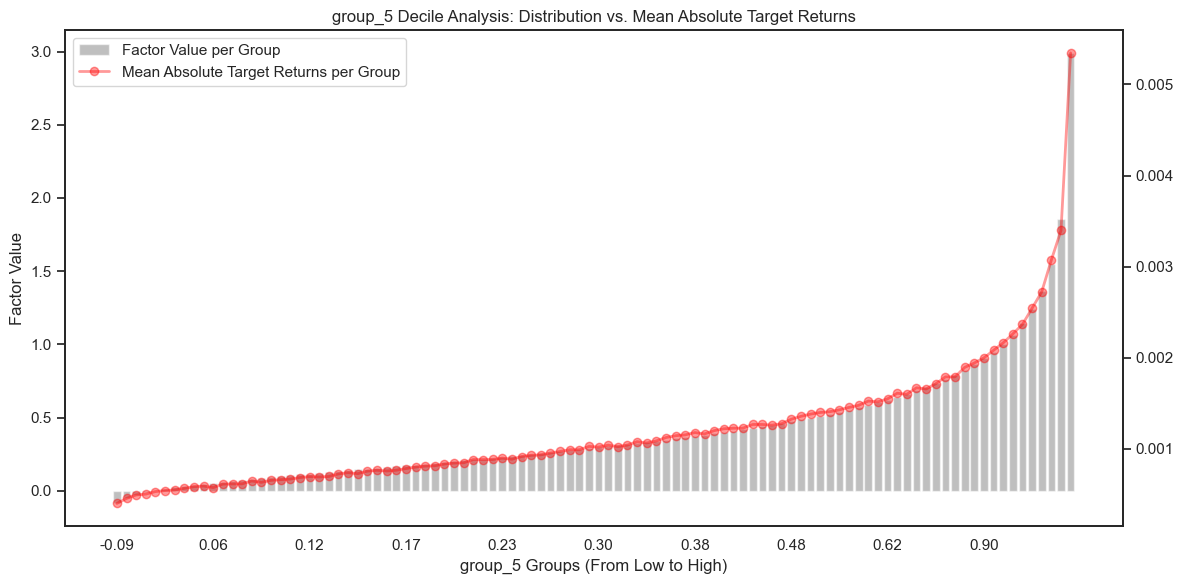

Group 6 Spearman IC with Target Returns Abs: 0.0233


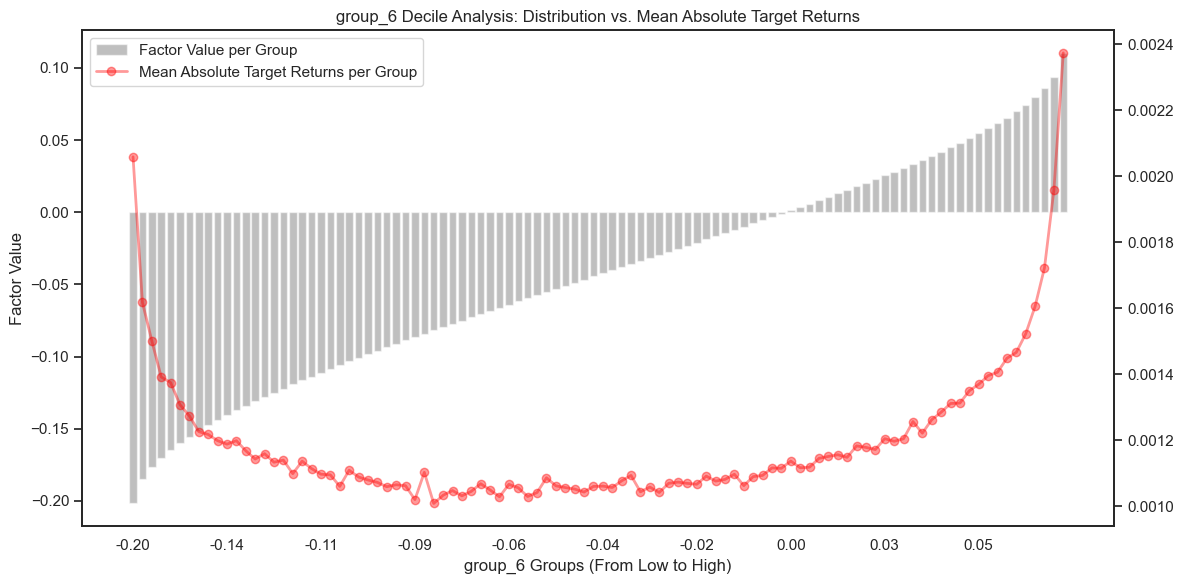

Group 7 Spearman IC with Target Returns Abs: 0.0296


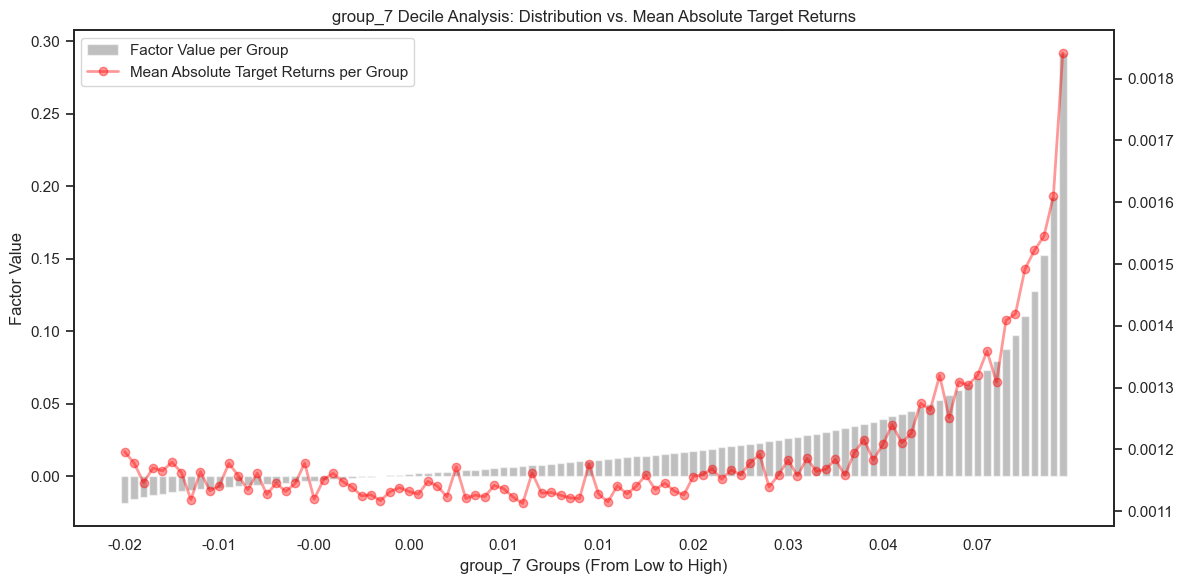

Group 8 Spearman IC with Target Returns Abs: 0.4483


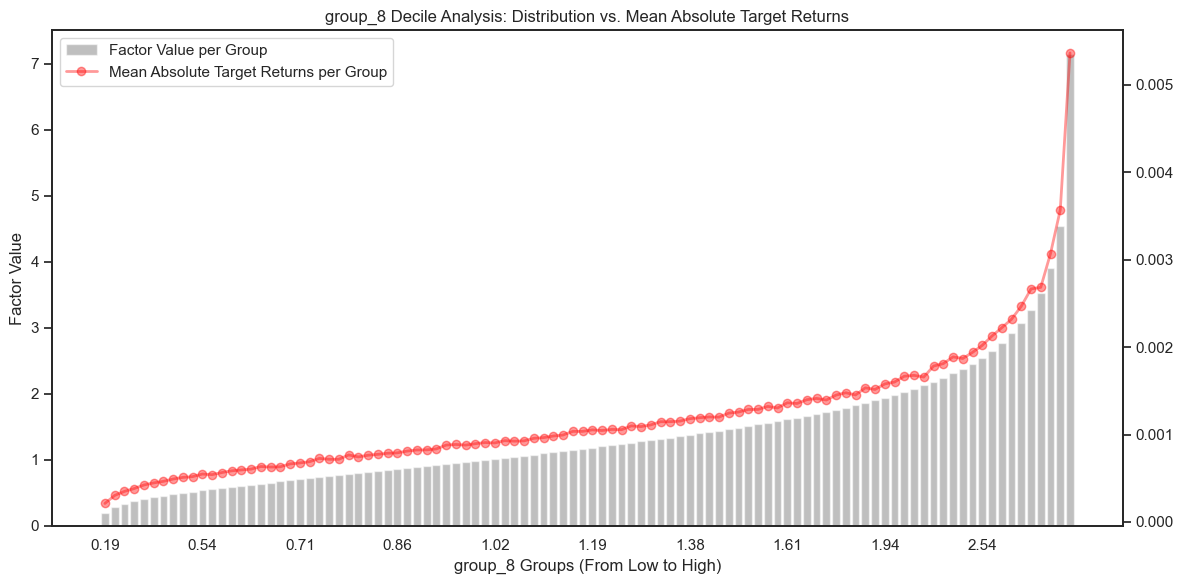

Group 9 Spearman IC with Target Returns Abs: 0.4756


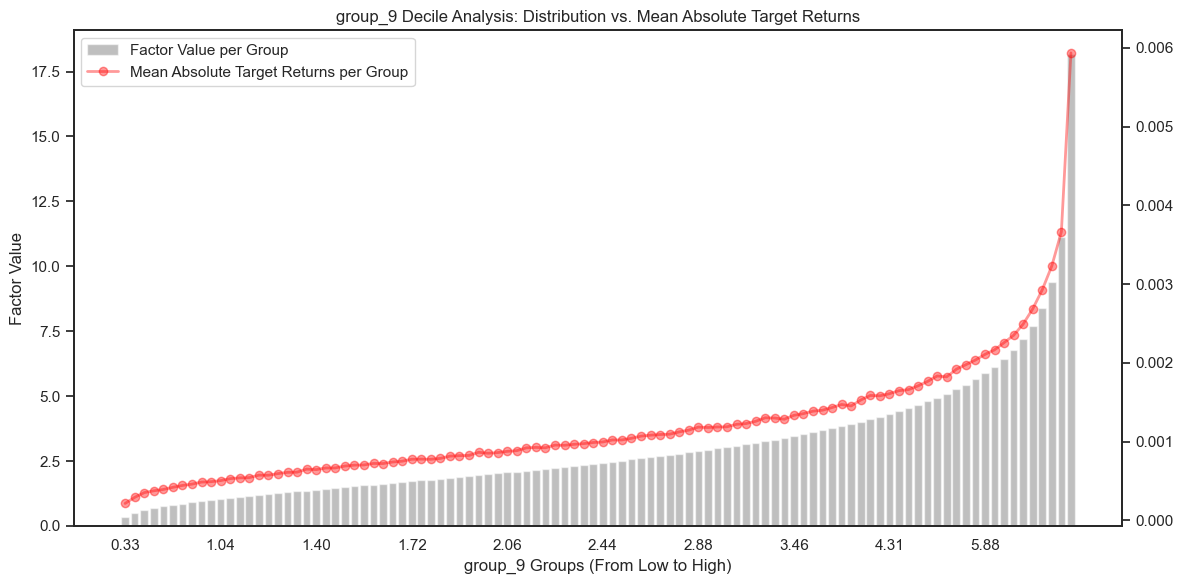

In [152]:
df_final = pd.DataFrame(index=factors.index)

for i in range(0,10):
    df_final[f"group_{i}"] = 0
    for factor in group_split[i]:
        ic = factors[factor].corr(target_returns.abs(), method='spearman')
        std = factors[factor].std()
        df_final[f"group_{i}"] += factors[factor] * ic / std
    final_ic = df_final[f"group_{i}"][df_final[f"group_{i}"]!=0].corr(target_returns.abs(), method='spearman')
    print(f"Group {i} Spearman IC with Target Returns Abs: {final_ic:.4f}")
    plot_factor_ic_bar(df_final[f"group_{i}"][df_final[f"group_{i}"]!=0], target_returns.abs(), factor_name=f"group_{i}", result_name="Absolute Target Returns", bins=100)

# 2. 组间合成

In [86]:
df_final.describe()

,group_0,group_3,group_8,group_9
count,745326.000000,745326.000000,745326.000000,745326.000000
mean,0.472550,-0.202699,1.410807,3.076357
std,0.582765,0.234279,1.035746,2.631461
min,0.000000,-2.724693,0.000000,0.000000
25%,0.153362,-0.362726,0.778187,1.540448
50%,0.315668,-0.164415,1.175709,2.412940
75%,0.589675,0.000000,1.742256,3.796618
max,48.554462,0.000000,27.337736,111.265448


In [ ]:
# 算了先线性合成试试万一成了呢

Final Alpha Spearman IC with Target Returns Abs: 0.4629


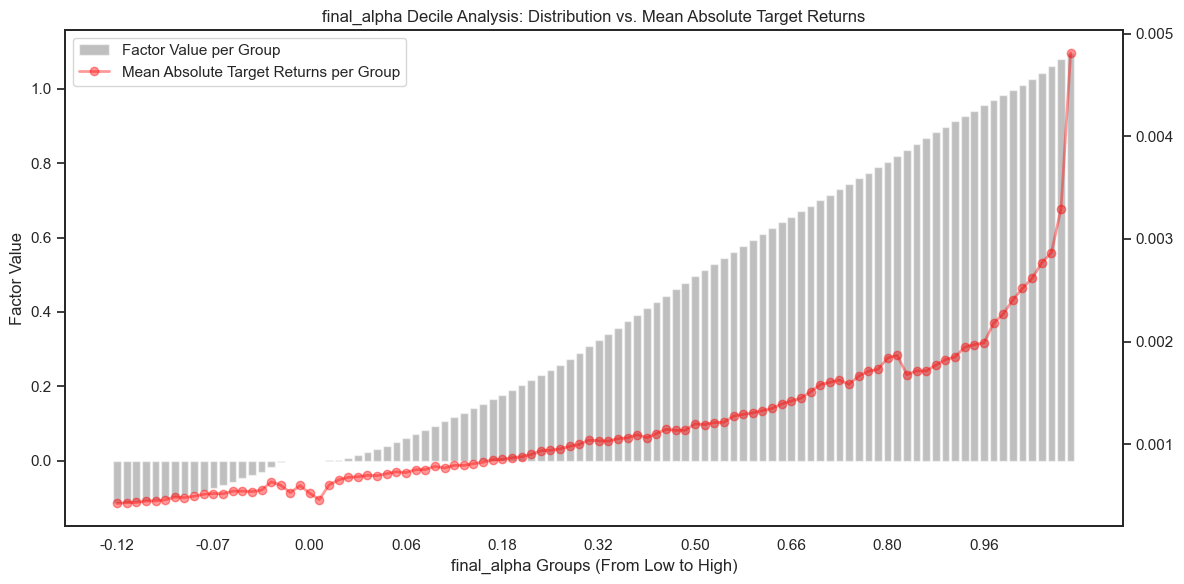

In [160]:
# 对每个组进行curve
import numpy as np

def pseudo_zero_one(series, threshold=0.5, k=5):
    """
    threshold: 只有超过这个分位数的信号才开始激活 (0.7 代表前 30%)
    k: 斜率。k 越大，函数越接近硬性的 0/1 阶梯
    """
    # 1. 滚动 Rank (144 bar 约为 12 小时)
    # 如果你不想滚动，直接用 rank(pct=True) 也可以，但滚动更实盘
    r = series.rank(pct=True)
    
    # 2. 只有正向极性处理 (Group 3 这种负向的需要先取绝对值或反向)
    # 假设我们已经把所有组都调成了“数值越大波幅越大”
    
    x_shifted = np.maximum(0, r - threshold)
    
    # 3. 映射到 0-1
    # 缩放 x 让它在 threshold 到 1 之间能覆盖 exp 的主要变化区
    # 当 r=1 时，exp(-k*(1-threshold)) 应该接近 0
    return (1 - np.exp(-k * x_shifted))**3

# 假设 df_final 是你贴出的那个 DataFrame

# 1. 极性对齐 (让 Group 3 变正向，因为它 min 是 -2.7, max 是 0)
df_final['group_3_aligned'] = -df_final['group_3'] 

groups_to_process = ['group_0', 'group_3_aligned', 'group_8', 'group_9']

# 2. 批量生成“伪 01”信号
df_signals = pd.DataFrame(index=df_final.index)
df_final['final_alpha'] = 0
for col in groups_to_process:
    # 选 threshold=0.7 是为了过滤底噪，k=10 会让斜率在 0.7 之后迅速变陡
    df_signals[col + '_sig'] = pseudo_zero_one(df_final[col], threshold=0.3, k=5)
    ic = df_signals[col + '_sig'].corr(target_returns.abs(), method='spearman')
    df_final['final_alpha'] += df_signals[col + '_sig'] * ic  # 用 IC 作为权重
# 3. 最终加权投票 (既然目测 0.28 和 0.32 没差，直接等权)



# 4. 评估最终 alpha 的 IC
final_ic = df_final['final_alpha'].corr(target_returns.abs(), method='spearman')
print(f"Final Alpha Spearman IC with Target Returns Abs: {final_ic:.4f}")
plot_factor_ic_bar(df_final['final_alpha'], target_returns.abs(), factor_name='final_alpha', result_name="Absolute Target Returns", bins=100)

In [161]:
df_final.to_parquet("final_signal.parquet")

Final Alpha Spearman IC with Target Returns Abs: 0.4549


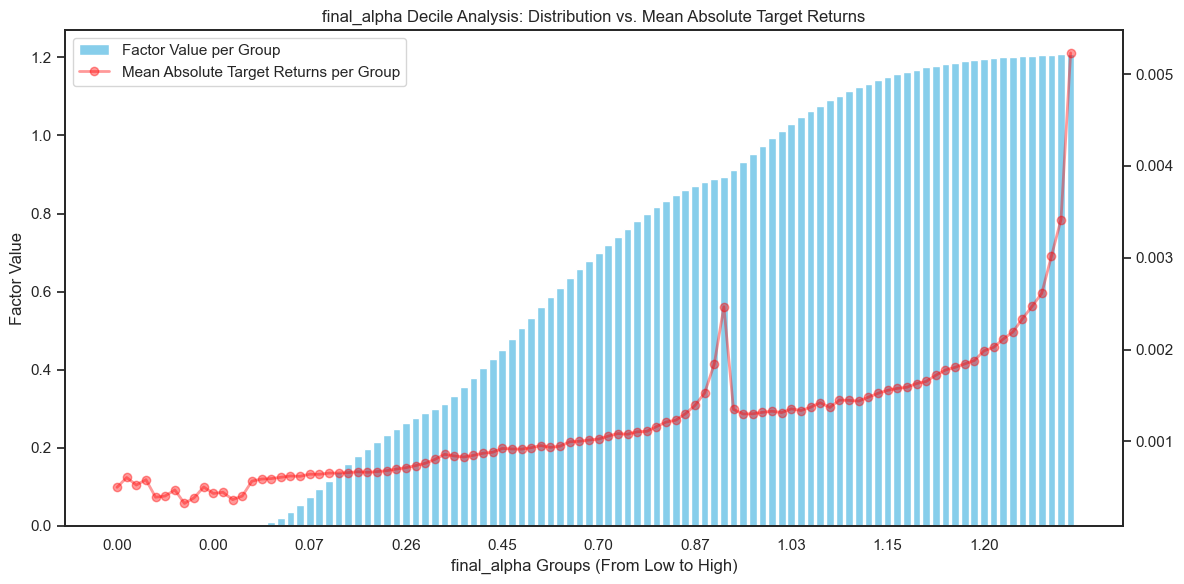

In [128]:
# 对每个组进行curve
import numpy as np

def pseudo_zero_one(series, threshold=0.5, k=5):
    """
    threshold: 只有超过这个分位数的信号才开始激活 (0.7 代表前 30%)
    k: 斜率。k 越大，函数越接近硬性的 0/1 阶梯
    """
    # 1. 滚动 Rank (144 bar 约为 12 小时)
    # 如果你不想滚动，直接用 rank(pct=True) 也可以，但滚动更实盘
    r = series.rank(pct=True)
    
    # 2. 只有正向极性处理 (Group 3 这种负向的需要先取绝对值或反向)
    # 假设我们已经把所有组都调成了“数值越大波幅越大”
    
    x_shifted = np.maximum(0, r - threshold)
    
    # 3. 映射到 0-1
    # 缩放 x 让它在 threshold 到 1 之间能覆盖 exp 的主要变化区
    # 当 r=1 时，exp(-k*(1-threshold)) 应该接近 0
    return (1 - np.exp(-k * x_shifted))**3

# 假设 df_final 是你贴出的那个 DataFrame

# 1. 极性对齐 (让 Group 3 变正向，因为它 min 是 -2.7, max 是 0)
df_final['group_3_aligned'] = -df_final['group_3'] 

groups_to_process = ['group_0', 'group_8', 'group_9']

# 2. 批量生成“伪 01”信号
df_signals = pd.DataFrame(index=df_final.index)
df_final['final_alpha'] = 0
for col in groups_to_process:
    # 选 threshold=0.7 是为了过滤底噪，k=10 会让斜率在 0.7 之后迅速变陡
    df_signals[col + '_sig'] = pseudo_zero_one(df_final[col], threshold=0.3, k=10)
    ic = df_signals[col + '_sig'].corr(target_returns.abs(), method='spearman')
    df_final['final_alpha'] += df_signals[col + '_sig'] * ic   # 用 IC 作为权重
# 3. 最终加权投票 (既然目测 0.28 和 0.32 没差，直接等权)

# 4. 评估最终 alpha 的 IC
final_ic = df_final['final_alpha'].corr(target_returns.abs()[df_final['final_alpha'].notnull()], method='spearman')
print(f"Final Alpha Spearman IC with Target Returns Abs: {final_ic:.4f}")
plot_factor_ic_bar(df_final['final_alpha'], target_returns.abs(), factor_name='final_alpha', result_name="Absolute Target Returns", bins=100)

# 11.  进行组内PCA
  但实际上组内PCA没有明显提升，甚至有些组的表现变差了，所以放弃了组内PCA

In [82]:
import numpy as np
import pandas as pd

def fast_rolling_pca(df_group, window=144):
    data = df_group.values
    n_samples, n_features = data.shape
    out = np.full(n_samples, np.nan)
    
    # 预先计算所有可能的滑动窗口索引 (或者直接用手动滑动)
    # 为了极致速度，我们只处理关键运算
    for i in range(window, n_samples):
        # 1. 快速 Robust Scaling (NumPy 向量化)
        chunk = data[i-window:i, :]
        median = np.median(chunk, axis=0)
        # 使用 percentile 替代 quantile
        q75, q25 = np.percentile(chunk, [75, 25], axis=0)
        iqr = q75 - q25
        iqr[iqr == 0] = 1e-6
        
        # 标准化当前窗口
        scaled_chunk = (chunk - median) / iqr
        
        # 2. 计算协方差矩阵 (C = X^T * X)
        # 对于 PC1，协方差矩阵足够了，n_features 很小，这一步极快
        cov_mat = np.cov(scaled_chunk, rowvar=False)
        
        # 3. 特征值分解 (只取最大的特征向量)
        # eigh 专门用于对称矩阵，比 eig 快且稳
        eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
        
        # eigenvalues 是升序的，取最后一个
        loading = eigenvectors[:, -1]
        
        # 4. 符号对齐
        if np.mean(loading) < 0:
            loading = -loading
            
        # 5. 投影当前行
        current_row_scaled = (data[i] - median) / iqr
        out[i] = np.dot(current_row_scaled, loading)
        
    return pd.Series(out, index=df_group.index)

In [19]:
group_eff = [0,8, 9]
for i in group_eff:
    factor_list = group_split[i]
    df_group = factors[factor_list]
    pca_signal = fast_rolling_pca(df_group, window=144)
    # 计算与目标的相关性
    ic = pca_signal.corr(target_returns.abs(), method='spearman')
    print(f"Group {i} PCA Signal Spearman IC: {ic:.4f}")

Group 0 PCA Signal Spearman IC: 0.1014
Group 8 PCA Signal Spearman IC: 0.1680
Group 9 PCA Signal Spearman IC: 0.1771


# 12. 因子相关性热力图

In [85]:
from test_tools import plot_factor_corr

ImportError: cannot import name 'plot_factor_corr' from 'test_tools' (/Users/vela/Desktop/mev/factor/backtest/test_tools.py)

In [23]:
for i in [0,3,8]:
    group_0 = factors[group_split[i]]
    sum_0 = group_0.sum(axis=1)
    corr = sum_0.corr(target_returns.abs(), method='spearman')
    print(f"Group {i} Sum Spearman Correlation with Target Returns Abs: {corr:.4f}")

Group 0 Sum Spearman Correlation with Target Returns Abs: 0.3141
Group 3 Sum Spearman Correlation with Target Returns Abs: -0.1191
Group 8 Sum Spearman Correlation with Target Returns Abs: 0.2526


Group 0 Correlation Heatmap:


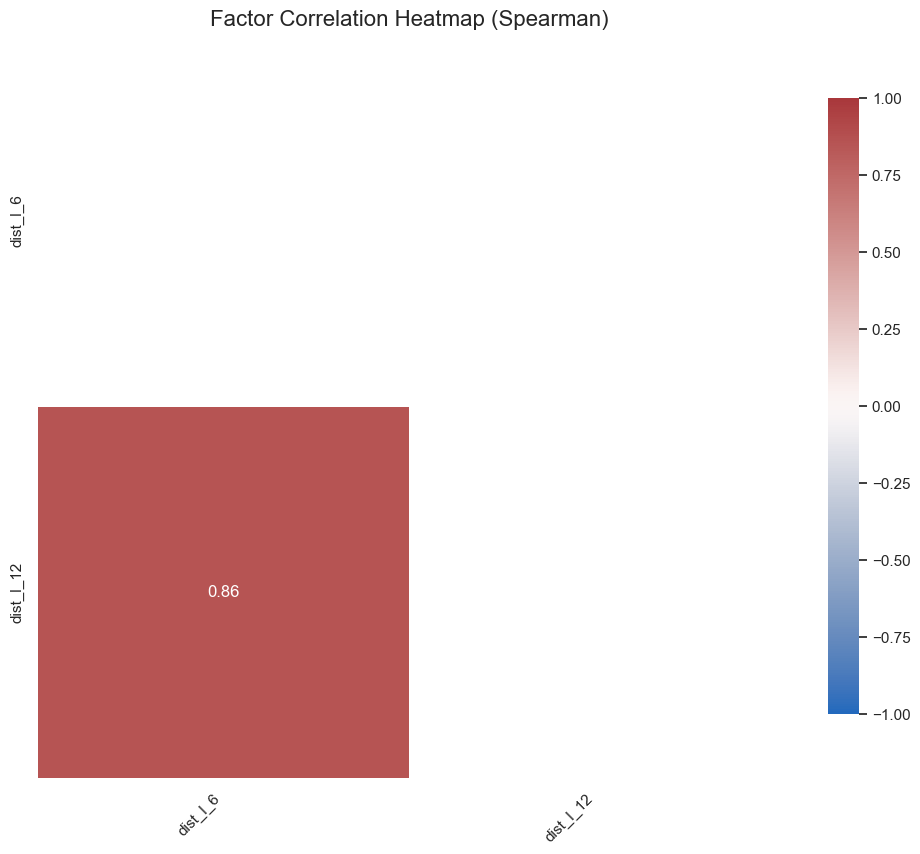

Group 0 Average Spearman IC: 0.3019
Group 3 Correlation Heatmap:


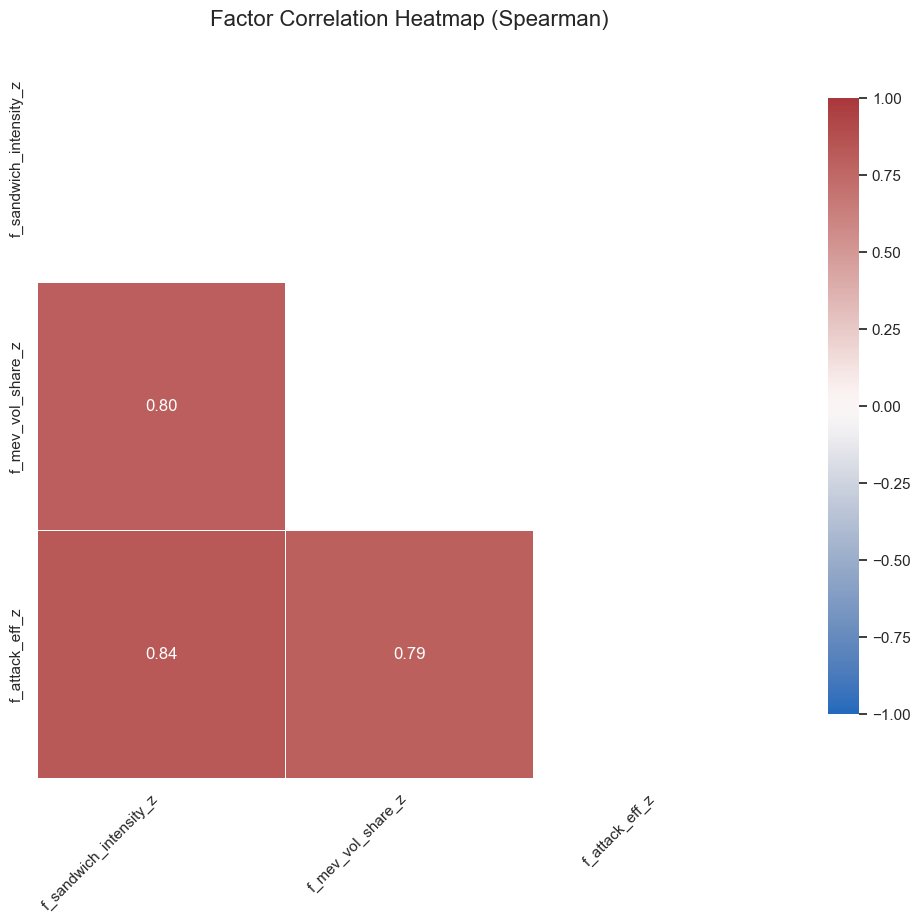

Group 3 Average Spearman IC: -0.1062
Group 5 Correlation Heatmap:


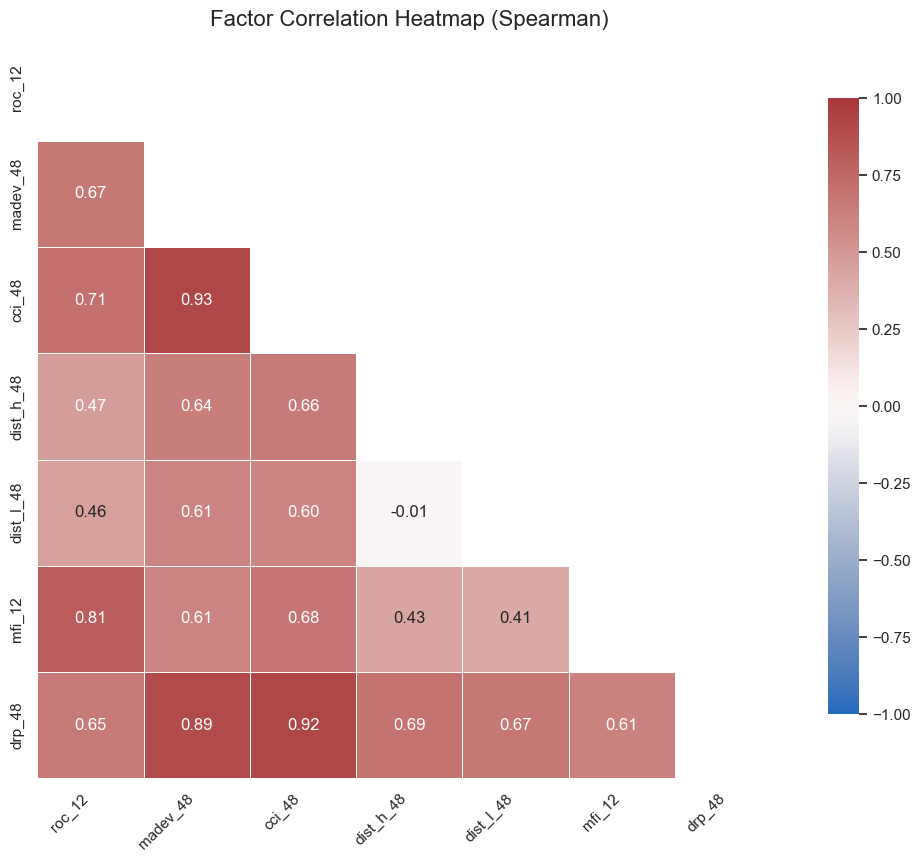

Group 5 Average Spearman IC: -0.0167
Group 8 Correlation Heatmap:


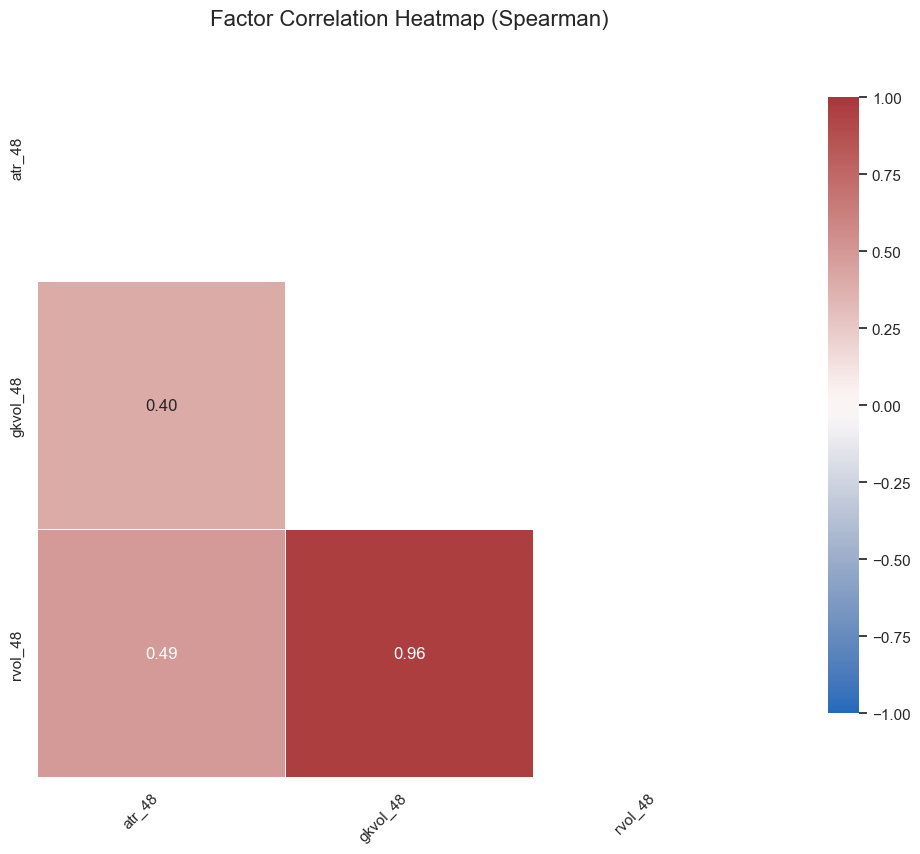

Group 8 Average Spearman IC: 0.3840
Group 9 Correlation Heatmap:


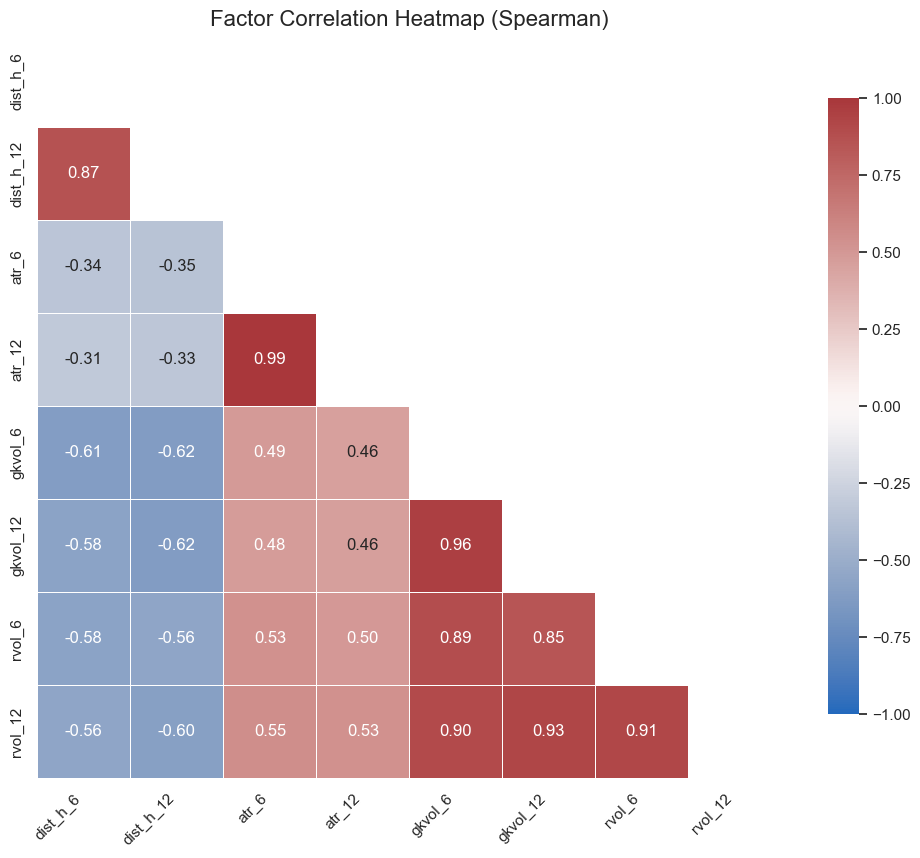

Group 9 Average Spearman IC: 0.2286


In [155]:
group_eff = [0, 3, 5,8, 9]
for i in group_eff:
    factor_list = group_split[i]
    df_group = factors[factor_list]
    print(f"Group {i} Correlation Heatmap:")
    plot_factor_corr(df_group, method='spearman')
    ic = df_group.corrwith(target_returns.abs(), method='spearman')
    print(f"Group {i} Average Spearman IC: {ic.mean():.4f}")

In [156]:
from test_tools import effective_days
from test_tools import get_jaccard_similarity

persistence = effective_days(df_final[[f"group_{i}" for i in group_eff]], target_returns.abs(), window = 72, threshold=0.1)
jaccard_similarity = get_jaccard_similarity(persistence)
print("\nFactor Jaccard Similarity Matrix:")
print(jaccard_similarity)


Factor Jaccard Similarity Matrix:
          group_0   group_3   group_5   group_8   group_9
group_0  1.000000  0.211426  0.413220  0.381829  0.427202
group_3  0.211426  1.000000  0.216234  0.215770  0.232753
group_5  0.413220  0.216234  1.000000  0.448411  0.503947
group_8  0.381829  0.215770  0.448411  1.000000  0.436703
group_9  0.427202  0.232753  0.503947  0.436703  1.000000


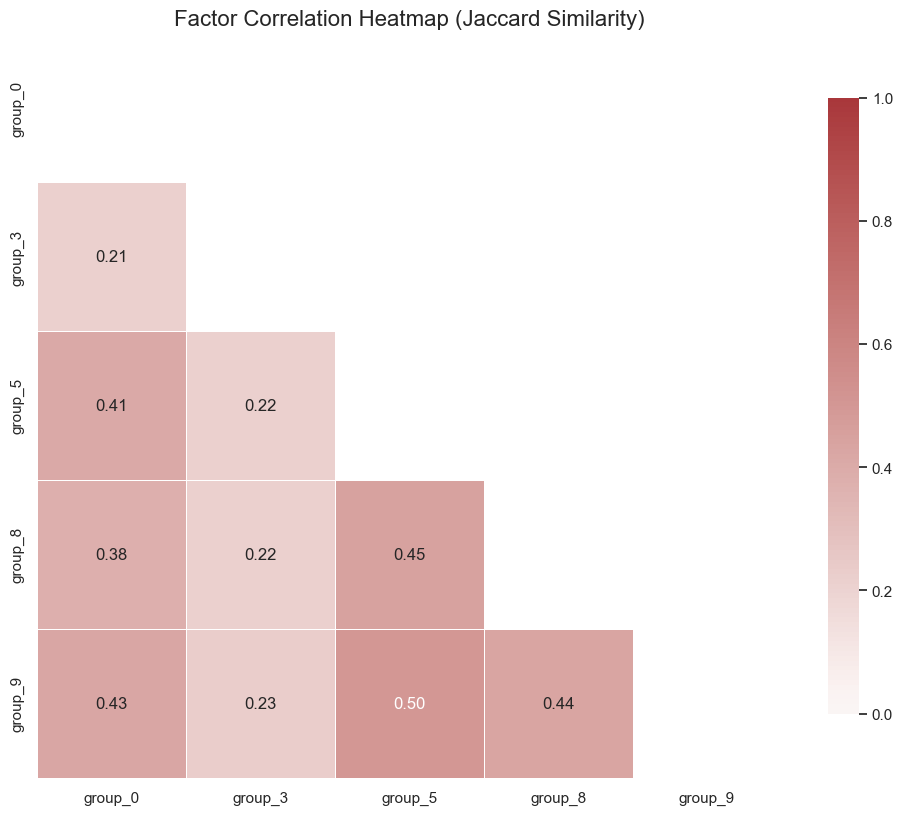

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = jaccard_similarity
sns.set_theme(style="white")
plt.figure(figsize=(12, 10))
    
    # 3. 绘制热力图
    # mask: 隐藏右上角重复的三角形，让视觉更聚焦
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,           # 显示具体数值
    fmt=".2f",            # 保留两位小数
    cmap='vlag',          # 蓝红配色，0为白色，正负分明
    vmin=0,               # 颜色映射下限
    vmax=1,               # 颜色映射上限
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
    )
    
plt.title(f'Factor Correlation Heatmap (Jaccard Similarity)', fontsize=16)
plt.show()

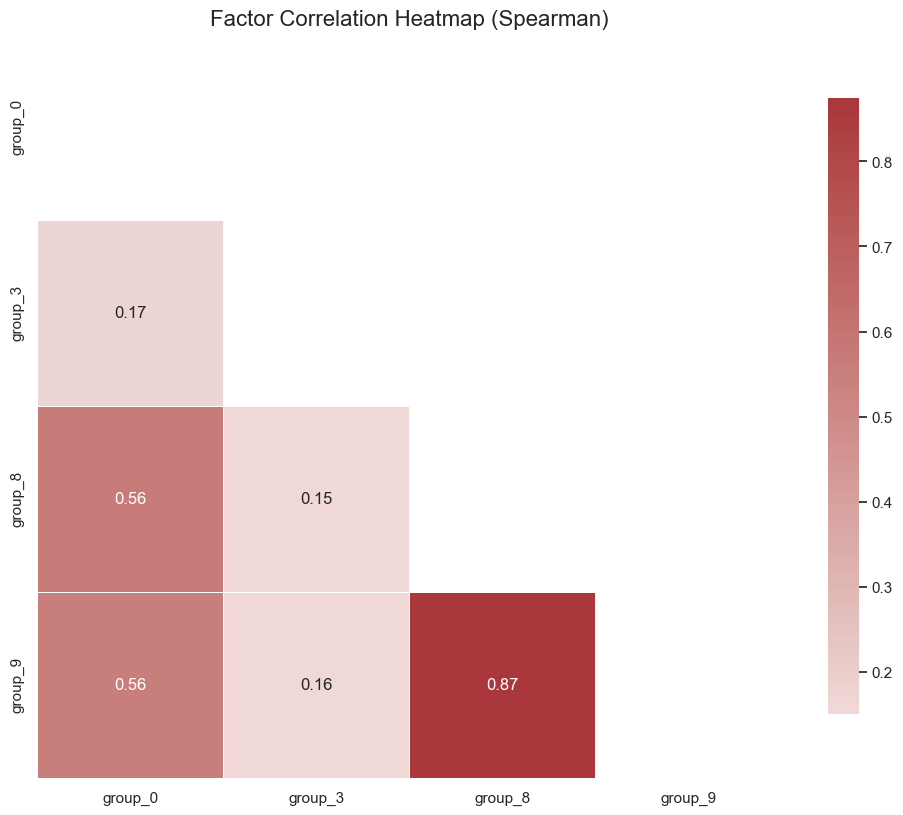

In [68]:
plot_factor_corr(df_final)

In [ ]:
# 获取描述性统计
# 准备数据
market = pd.read_parquet("../data_ohlcv.parquet")
f_mev = pd.read_parquet("../factors_mev_new.parquet")
f_ohlcv = pd.read_parquet("../factors_ohlcv.parquet")
f_ohlcv = f_ohlcv.fillna(0)
target_returns = market['close'].pct_change().shift(-1) 
factors = pd.concat([f_mev, f_ohlcv], axis=1, join='outer')
# 清洗数据
factors = factors.replace([np.inf, -np.inf], np.nan)
factors = factors.fillna(0)

In [129]:
print(factors.columns)

Index(['f_sandwich_intensity_z', 'f_mev_vol_share_z', 'f_attack_eff_z',
       'roc_6', 'roc_12', 'roc_48', 'madev_6', 'madev_12', 'madev_48', 'cci_6',
       'cci_12', 'cci_48', 'dist_h_6', 'dist_h_12', 'dist_h_48', 'dist_l_6',
       'dist_l_12', 'dist_l_48', 'cmf_6', 'cmf_12', 'cmf_48', 'volsu_6',
       'volsu_12', 'volsu_48', 'mfi_6', 'mfi_12', 'mfi_48', 'avr_6', 'avr_12',
       'avr_48', 'atr_6', 'atr_12', 'atr_48', 'gkvol_6', 'gkvol_12',
       'gkvol_48', 'rvol_6', 'rvol_12', 'rvol_48', 'skew_6', 'skew_12',
       'skew_48', 'kurt_6', 'kurt_12', 'kurt_48', 'drp_6', 'drp_12', 'drp_48',
       'pvcorr_6', 'pvcorr_12', 'pvcorr_48', 'rank_6', 'rank_12', 'rank_48',
       'corr_6', 'corr_12', 'corr_48', 'delta_6', 'delta_12', 'delta_48'],
      dtype='object')


In [130]:
selected_list = ["roc_6","cci_6","cmf_6","gkvol_6","skew_6","corr_6","f_sandwich_intensity_z","f_mev_vol_share_z","f_attack_eff_z"]
df_to_describe = factors[selected_list]
df_to_describe["target_returns"] = target_returns
print(df_to_describe.describe())


/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_61973/2726632873.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_describe["target_returns"] = target_returns


               roc_6          cci_6          cmf_6        gkvol_6  \
count  745326.000000  745326.000000  745326.000000  745326.000000   
mean        0.000036       0.639124       0.013549       0.001521   
std         0.004855      74.074091       0.267527       0.001409   
min        -0.202199    -136.082764      -1.000000       0.000000   
25%        -0.001651     -67.336910      -0.169350       0.000730   
50%         0.000026       1.680301       0.013229       0.001174   
75%         0.001734      68.259038       0.196345       0.001876   
max         0.336439     142.614944       1.000000       0.069743   

              skew_6         corr_6  f_sandwich_intensity_z  \
count  745326.000000  745326.000000           745326.000000   
mean        0.014069      -0.011683                0.745775   
std         0.896418       0.541185                0.910481   
min        -2.449490      -1.000000                0.000000   
25%        -0.592600      -0.477617                0.000000   


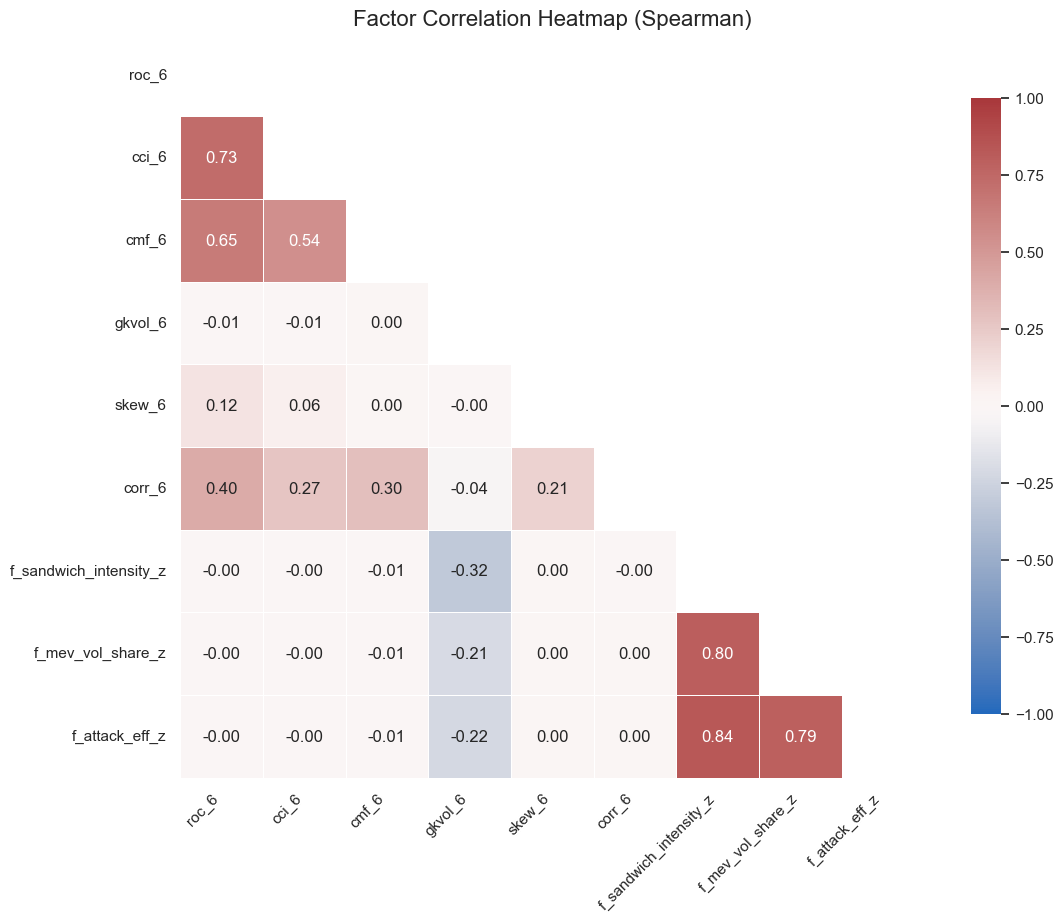

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_factor_corr(df_factors, method='spearman'):
    """
    绘制因子相关性热力图
    method: 'pearson' 或 'spearman' (量化通常用后者，因为对异常值不敏感)
    """
    # 1. 计算相关系数矩阵
    corr_matrix = df_factors.corr(method=method)
    
    # 2. 设置绘图风格
    sns.set_theme(style="white")
    plt.figure(figsize=(12, 10))
    
    # 3. 绘制热力图
    # mask: 隐藏右上角重复的三角形，让视觉更聚焦
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    heatmap = sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True,           # 显示具体数值
        fmt=".2f",            # 保留两位小数
        cmap='vlag',          # 蓝红配色，0为白色，正负分明
        center=0,
        vmin = -1,
        vmax = 1,
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .8}
    )
    
    plt.title(f'Factor Correlation Heatmap ({method.capitalize()})', fontsize=16)
    plt.xticks(rotation=45, ha='right')  # 调整标签旋转和对齐
    plt.show()
plot_factor_corr(df_to_describe[selected_list], method='spearman')